In [14]:
# Uncomment if running for the first time
# !pip install pandas matplotlib seaborn openpyxl

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Colour palette ──────────────────────────────────────────────────────────
BLUE   = "#378ADD"
GREEN  = "#1D9E75"
AMBER  = "#BA7517"
PURPLE = "#534AB7"
PINK   = "#D4537E"
RED    = "#E24B4A"
GRAY   = "#888780"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#e8e8e8",
    "grid.linewidth":   0.6,
    "font.family":      "sans-serif",
    "font.size":        11,
})

def fmt_k(x, _):
    return f"{x/1000:.0f}k"

print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


## 1. Load & feature engineer

In [15]:
# ── Update this path if needed ──────────────────────────────────────────────
FILE_PATH = "/kaggle/input/datasets/vivo777/dataset/Energy Consumption Dataset.xlsx"   # Colab
# FILE_PATH = "Energy_Consumption_Dataset.xlsx"          # local

df = pd.read_excel(FILE_PATH)
df.columns = ["start", "end", "mwh"]
df["start"] = pd.to_datetime(df["start"])

# Derived time features
df["year"]  = df["start"].dt.year
df["month"] = df["start"].dt.month
df["hour"]  = df["start"].dt.hour
df["dow"]   = df["start"].dt.dayofweek          # 0 = Monday
df["week"]  = df["start"].dt.isocalendar().week.astype(int)
df["date"]  = df["start"].dt.date

print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape  : (52966, 9)
Columns: ['start', 'end', 'mwh', 'year', 'month', 'hour', 'dow', 'week', 'date']


,start,end,mwh,year,month,hour,dow,week,date
0,2015-12-31 21:00:00,2015-12-31 22:00:00,10800,2015,12,21,3,53,2015-12-31
1,2015-12-31 22:00:00,2015-12-31 23:00:00,10431,2015,12,22,3,53,2015-12-31
2,2015-12-31 23:00:00,2016-01-01 00:00:00,10005,2015,12,23,3,53,2015-12-31
3,2016-01-01 00:00:00,2016-01-01 01:00:00,9722,2016,1,0,4,53,2016-01-01
4,2016-01-01 01:00:00,2016-01-01 02:00:00,9599,2016,1,1,4,53,2016-01-01


## 2. Statistical summary

In [16]:
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows          : {len(df):,}")
print(f"  Date range    : {df['start'].min().date()} → {df['start'].max().date()}")
print(f"  Missing values: {df.isnull().sum().sum()}")

print("\n── Descriptive statistics (MWh) ──")
s = df["mwh"].describe()
for k, v in s.items():
    print(f"  {k:10s}: {v:>10,.1f}")
print(f"  {'skewness':10s}: {df['mwh'].skew():>10.4f}")
print(f"  {'kurtosis':10s}: {df['mwh'].kurt():>10.4f}")

  DATASET OVERVIEW
  Rows          : 52,966
  Date range    : 2015-12-31 → 2021-12-31
  Missing values: 0

── Descriptive statistics (MWh) ──
  count     :   52,966.0
  mean      :    9,488.8
  std       :    1,576.2
  min       :    5,341.0
  25%       :    8,322.0
  50%       :    9,277.0
  75%       :   10,602.0
  max       :   15,105.0
  skewness  :     0.4014
  kurtosis  :    -0.3345


In [17]:
q1, q3 = df["mwh"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr
high = df[df["mwh"] > upper_fence]
low  = df[df["mwh"] < lower_fence]

print("── Outliers (IQR method) ──")
print(f"  IQR           : {iqr:,.0f} MWh")
print(f"  Upper fence   : {upper_fence:,.0f} MWh")
print(f"  Lower fence   : {lower_fence:,.0f} MWh")
print(f"  High outliers : {len(high):,} ({100*len(high)/len(df):.2f}%)")
print(f"  Low outliers  : {len(low):,}  ({100*len(low)/len(df):.2f}%)")

── Outliers (IQR method) ──
  IQR           : 2,280 MWh
  Upper fence   : 14,022 MWh
  Lower fence   : 4,902 MWh
  High outliers : 126 (0.24%)
  Low outliers  : 0  (0.00%)


In [18]:
print("── Yearly summary ──")
yrly = df.groupby("year")["mwh"].agg(["mean","min","max","sum"]).round(0)
display(yrly)

print("\n── Monthly mean (MWh) ──")
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
mo = df.groupby("month")["mwh"].mean().round(0)
for m, v in zip(months, mo):
    print(f"  {m}: {v:>8,.0f}")

print("\n── Day-of-week mean (MWh) ──")
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow = df.groupby("dow")["mwh"].mean().round(0)
for d, v in zip(days, dow):
    print(f"  {d}: {v:>8,.0f}")

── Yearly summary ──


,mean,min,max,sum
year,,,,
2015,10412.0,10005,10800,31236
2016,9553.0,5593,15105,84102180
2017,9522.0,5854,14273,83345248
2018,9792.0,6348,14062,85767200
2019,9482.0,5455,14542,86194868
2020,8916.0,5341,12388,78464338
2021,9670.0,6450,14267,84676090



── Monthly mean (MWh) ──
  Jan:   11,457
  Feb:   11,311
  Mar:   10,665
  Apr:    9,380
  May:    8,321
  Jun:    7,833
  Jul:    7,894
  Aug:    8,179
  Sep:    8,553
  Oct:    9,428
  Nov:   10,294
  Dec:   10,711

── Day-of-week mean (MWh) ──
  Mon:    9,624
  Tue:    9,650
  Wed:    9,659
  Thu:    9,681
  Fri:    9,707
  Sat:    9,167
  Sun:    8,932


## 3. Time-series overview

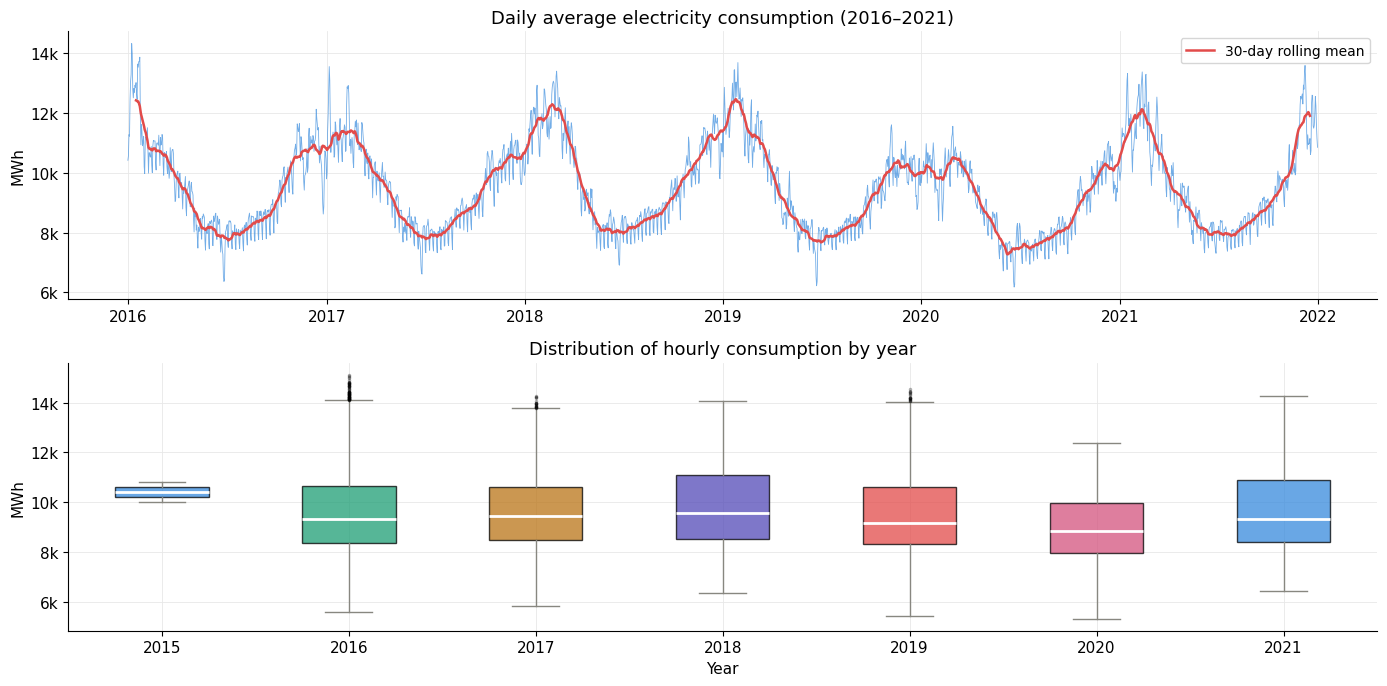

In [19]:
daily = df.groupby("date")["mwh"].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Full series + rolling mean
ax = axes[0]
ax.plot(daily.index, daily.values, color=BLUE, lw=0.6, alpha=0.7)
roll = daily.rolling(30, center=True).mean()
ax.plot(roll.index, roll.values, color=RED, lw=1.8, label="30-day rolling mean")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_title("Daily average electricity consumption (2016–2021)", fontsize=13)
ax.set_ylabel("MWh")
ax.legend(fontsize=10)

# Yearly box plots
ax2 = axes[1]
yearly_data = [df[df["year"] == y]["mwh"].values for y in sorted(df["year"].unique())]
bp = ax2.boxplot(yearly_data, patch_artist=True, notch=False,
                 medianprops=dict(color="white", lw=2),
                 whiskerprops=dict(color=GRAY),
                 capprops=dict(color=GRAY),
                 flierprops=dict(marker=".", ms=3, alpha=0.3, color=GRAY))
colors = [BLUE, GREEN, AMBER, PURPLE, RED, PINK, BLUE]
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax2.set_xticklabels(sorted(df["year"].unique()))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax2.set_title("Distribution of hourly consumption by year", fontsize=13)
ax2.set_ylabel("MWh"); ax2.set_xlabel("Year")

plt.tight_layout()
plt.savefig("01_timeseries_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Hour × month heatmap

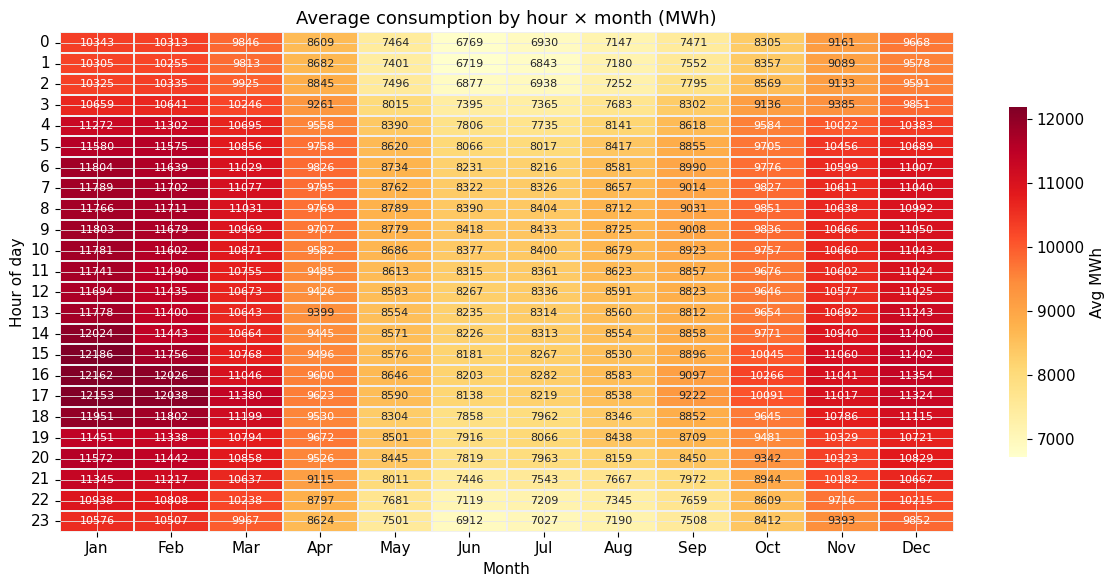

In [20]:
pivot = df.pivot_table(values="mwh", index="hour", columns="month", aggfunc="mean")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd",
            fmt=".0f", annot=True, annot_kws={"size": 8},
            linewidths=0.3, linecolor="#f0f0f0",
            cbar_kws={"label": "Avg MWh", "shrink": 0.7})
ax.set_title("Average consumption by hour × month (MWh)", fontsize=13)
ax.set_xlabel("Month"); ax.set_ylabel("Hour of day")
ax.tick_params(axis="x", rotation=0); ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("02_hour_month_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Monthly & hourly profiles

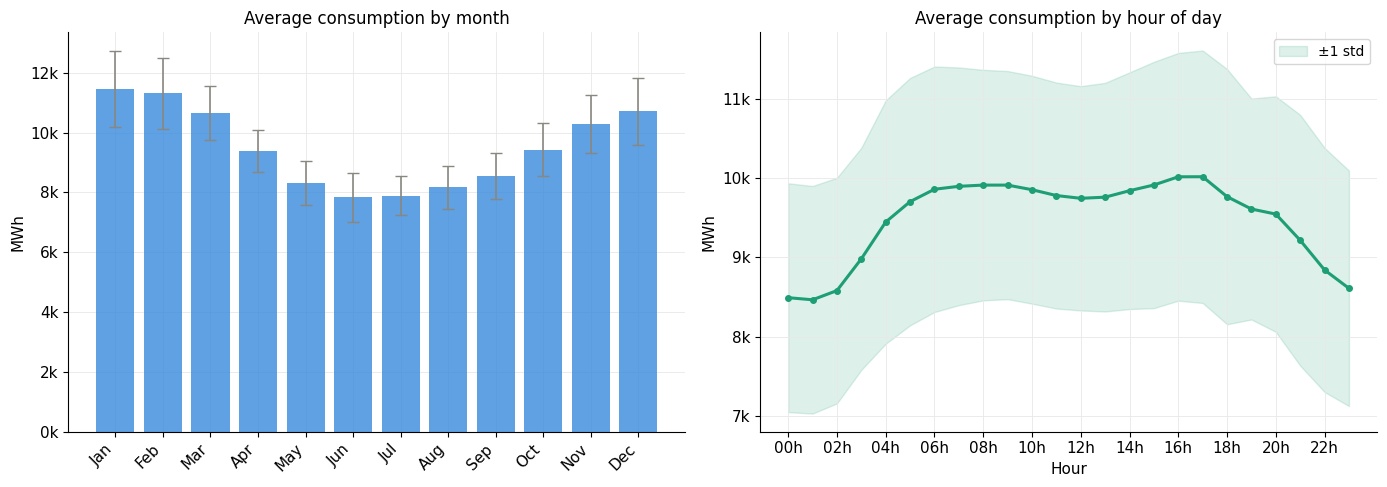

In [21]:
months_lbl = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
mo_mean = df.groupby("month")["mwh"].mean().values
mo_std  = df.groupby("month")["mwh"].std().values
hr_mean = df.groupby("hour")["mwh"].mean().values
hr_std  = df.groupby("hour")["mwh"].std().values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly bar
ax = axes[0]
ax.bar(range(1, 13), mo_mean, color=BLUE, alpha=0.8, zorder=2)
ax.errorbar(range(1, 13), mo_mean, yerr=mo_std, fmt="none",
            color=GRAY, capsize=4, lw=1.2)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(months_lbl, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_title("Average consumption by month", fontsize=12)
ax.set_ylabel("MWh")

# Hourly line with std band
ax2 = axes[1]
ax2.plot(range(24), hr_mean, color=GREEN, lw=2.2, marker="o", ms=4, zorder=3)
ax2.fill_between(range(24), hr_mean - hr_std, hr_mean + hr_std,
                 color=GREEN, alpha=0.15, label="±1 std")
ax2.set_xticks(range(0, 24, 2))
ax2.set_xticklabels([f"{h:02d}h" for h in range(0, 24, 2)])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax2.set_title("Average consumption by hour of day", fontsize=12)
ax2.set_ylabel("MWh"); ax2.set_xlabel("Hour"); ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig("03_monthly_hourly_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Weekday vs weekend analysis

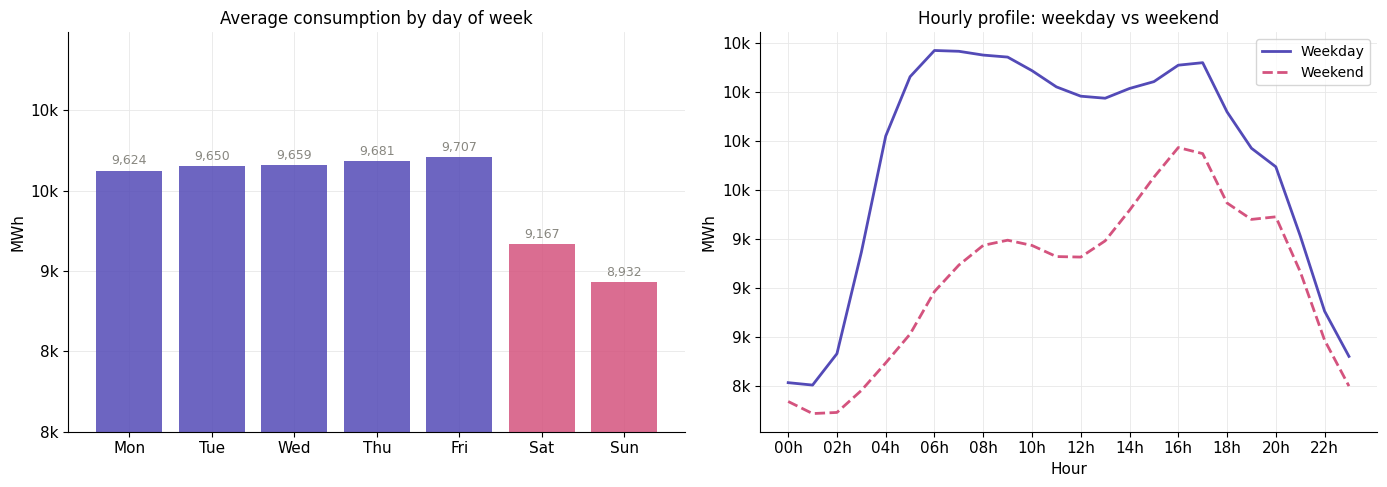

In [22]:
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_mean = df.groupby("dow")["mwh"].mean().values
bar_colors = [PURPLE]*5 + [PINK, PINK]
wd = df[df["dow"] < 5].groupby("hour")["mwh"].mean()
we = df[df["dow"] >= 5].groupby("hour")["mwh"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar by DOW
ax = axes[0]
bars = ax.bar(days, dow_mean, color=bar_colors, alpha=0.85, zorder=2)
ax.set_ylim(8000, dow_mean.max() * 1.08)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_title("Average consumption by day of week", fontsize=12)
ax.set_ylabel("MWh")
for bar, val in zip(bars, dow_mean):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=9, color=GRAY)

# Hourly profile comparison
ax2 = axes[1]
ax2.plot(range(24), wd, color=PURPLE, lw=2, label="Weekday")
ax2.plot(range(24), we, color=PINK,   lw=2, label="Weekend", linestyle="--")
ax2.set_xticks(range(0, 24, 2))
ax2.set_xticklabels([f"{h:02d}h" for h in range(0, 24, 2)])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax2.set_title("Hourly profile: weekday vs weekend", fontsize=12)
ax2.set_ylabel("MWh"); ax2.set_xlabel("Hour"); ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig("04_weekday_vs_weekend.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Distribution & outlier analysis

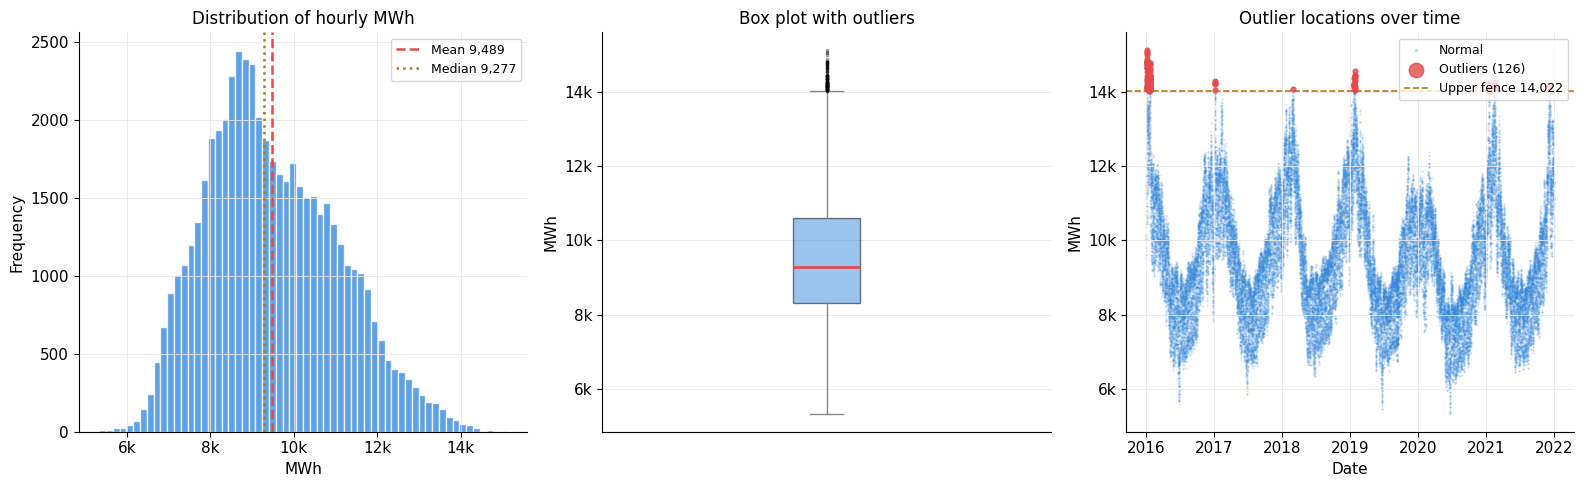


Outlier records:


,start,mwh
162,2016-01-07 15:00:00,15105
161,2016-01-07 14:00:00,15075
163,2016-01-07 16:00:00,15043
164,2016-01-07 17:00:00,14982
153,2016-01-07 06:00:00,14888
165,2016-01-07 18:00:00,14829
154,2016-01-07 07:00:00,14808
177,2016-01-08 06:00:00,14802
155,2016-01-07 08:00:00,14797
156,2016-01-07 09:00:00,14791


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
ax = axes[0]
ax.hist(df["mwh"], bins=60, color=BLUE, alpha=0.8, edgecolor="white", lw=0.4)
ax.axvline(df["mwh"].mean(),   color=RED,   lw=1.8, linestyle="--",
           label=f"Mean {df['mwh'].mean():,.0f}")
ax.axvline(df["mwh"].median(), color=AMBER, lw=1.8, linestyle=":",
           label=f"Median {df['mwh'].median():,.0f}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_title("Distribution of hourly MWh", fontsize=12)
ax.set_xlabel("MWh"); ax.set_ylabel("Frequency"); ax.legend(fontsize=9)

# Box plot
ax2 = axes[1]
ax2.boxplot(df["mwh"], vert=True, patch_artist=True,
            boxprops=dict(facecolor=BLUE, alpha=0.5),
            medianprops=dict(color=RED, lw=2),
            whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
            flierprops=dict(marker=".", ms=3, color=RED, alpha=0.4))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax2.set_title("Box plot with outliers", fontsize=12)
ax2.set_ylabel("MWh"); ax2.set_xticks([])

# Outlier scatter over time
ax3 = axes[2]
normal   = df[df["mwh"] <= upper_fence]
outliers = df[df["mwh"] >  upper_fence]
ax3.scatter(normal["start"],   normal["mwh"],   s=0.3, color=BLUE, alpha=0.2, label="Normal")
ax3.scatter(outliers["start"], outliers["mwh"], s=12,  color=RED,  alpha=0.8,
            label=f"Outliers ({len(outliers)})", zorder=5)
ax3.axhline(upper_fence, color=AMBER, lw=1.2, linestyle="--",
            label=f"Upper fence {upper_fence:,.0f}")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax3.set_title("Outlier locations over time", fontsize=12)
ax3.set_ylabel("MWh"); ax3.set_xlabel("Date"); ax3.legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.savefig("05_distribution_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nOutlier records:")
display(outliers[["start","mwh"]].sort_values("mwh", ascending=False).head(10))

## 8. Year-over-year monthly comparison

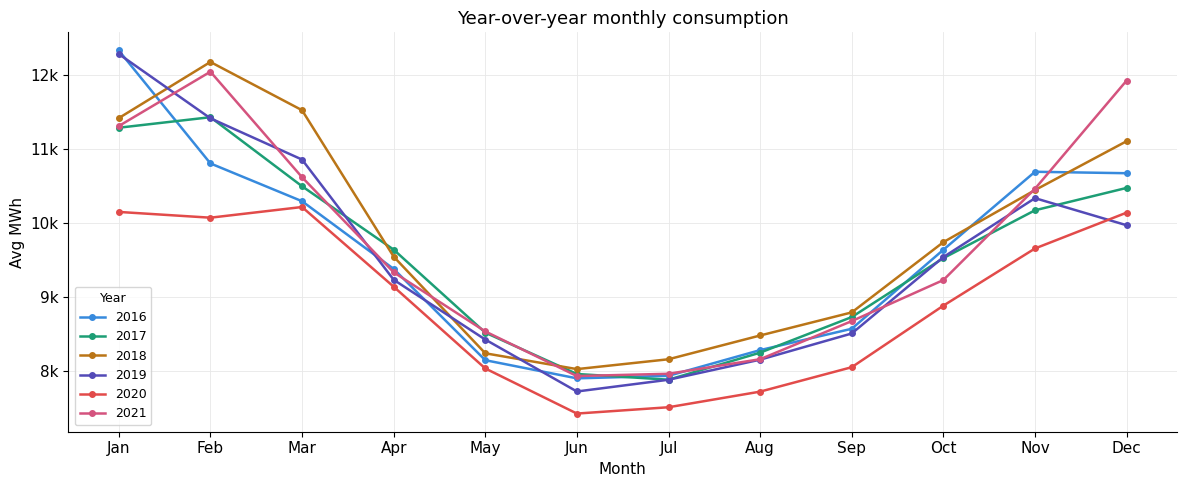

In [24]:
palette = [BLUE, GREEN, AMBER, PURPLE, RED, PINK]
years = sorted(y for y in df["year"].unique()
               if df[df["year"] == y]["month"].nunique() == 12)

fig, ax = plt.subplots(figsize=(12, 5))
months_lbl = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for yr, col in zip(years, palette):
    mo = df[df["year"] == yr].groupby("month")["mwh"].mean()
    ax.plot(range(1, 13), mo.values, color=col, lw=1.8, marker="o", ms=4, label=str(yr))

ax.set_xticks(range(1, 13)); ax.set_xticklabels(months_lbl)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_title("Year-over-year monthly consumption", fontsize=13)
ax.set_ylabel("Avg MWh"); ax.set_xlabel("Month")
ax.legend(title="Year", fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig("06_year_over_year.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Key observations

| Pattern | Finding |
|---|---|
| **Seasonality** | Winter peak (Jan ~11,457 MWh) vs summer trough (Jun ~7,833 MWh) — a **46% swing** |
| **Daily cycle** | Lowest at 1 AM (~8,466 MWh), peaks at 5 PM (~10,016 MWh) |
| **Weekend effect** | Weekdays avg ~9,664 MWh vs weekends ~9,050 MWh (~6.4% lower) |
| **2020 dip** | Annual avg dropped to 8,916 MWh — likely COVID-19 demand reduction |
| **Distribution** | Slightly right-skewed (skew = 0.40), centred around 9–10k MWh bin |
| **Outliers** | 126 high outliers (0.24%), zero low outliers — all above IQR upper fence of 14,022 MWh |

---
*Next: Advanced analysis — time series decomposition, anomaly detection, demand forecasting*

In [ ]:
import statsmodels.api as sm

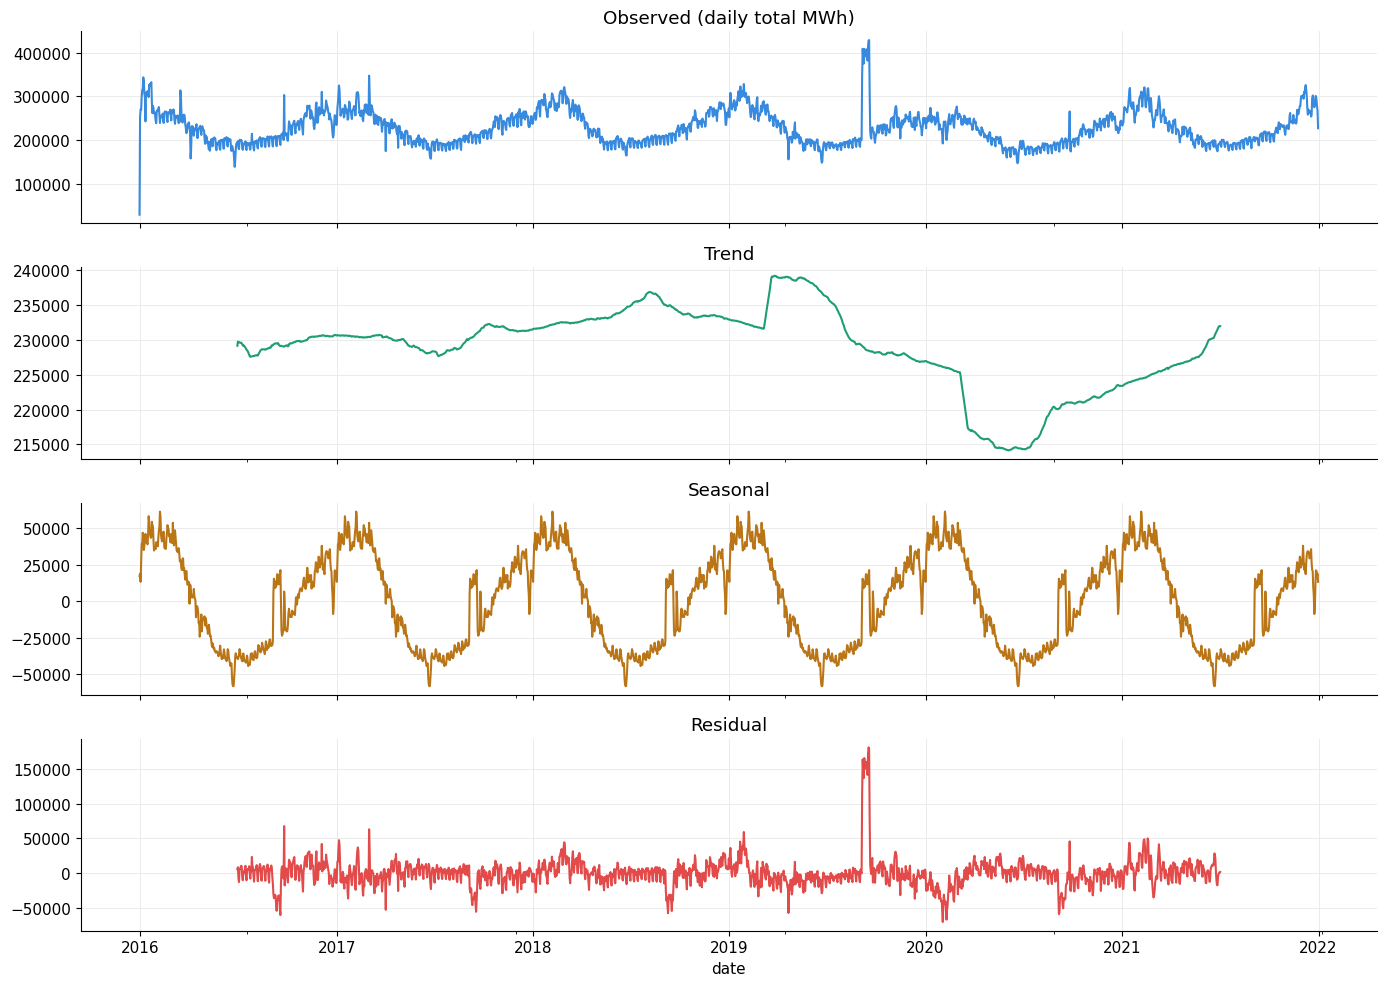

In [31]:
daily_total = df.groupby("date")["mwh"].sum().sort_index()
decomposition = sm.tsa.seasonal_decompose(daily_total, model="additive", period=365)
---
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], color=BLUE, title="Observed (daily total MWh)")
decomposition.trend.plot(ax=axes[1], color=GREEN, title="Trend")
decomposition.seasonal.plot(ax=axes[2], color=AMBER, title="Seasonal")
decomposition.resid.plot(ax=axes[3], color=RED, title="Residual")
plt.tight_layout()
plt.savefig("07_time_series_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

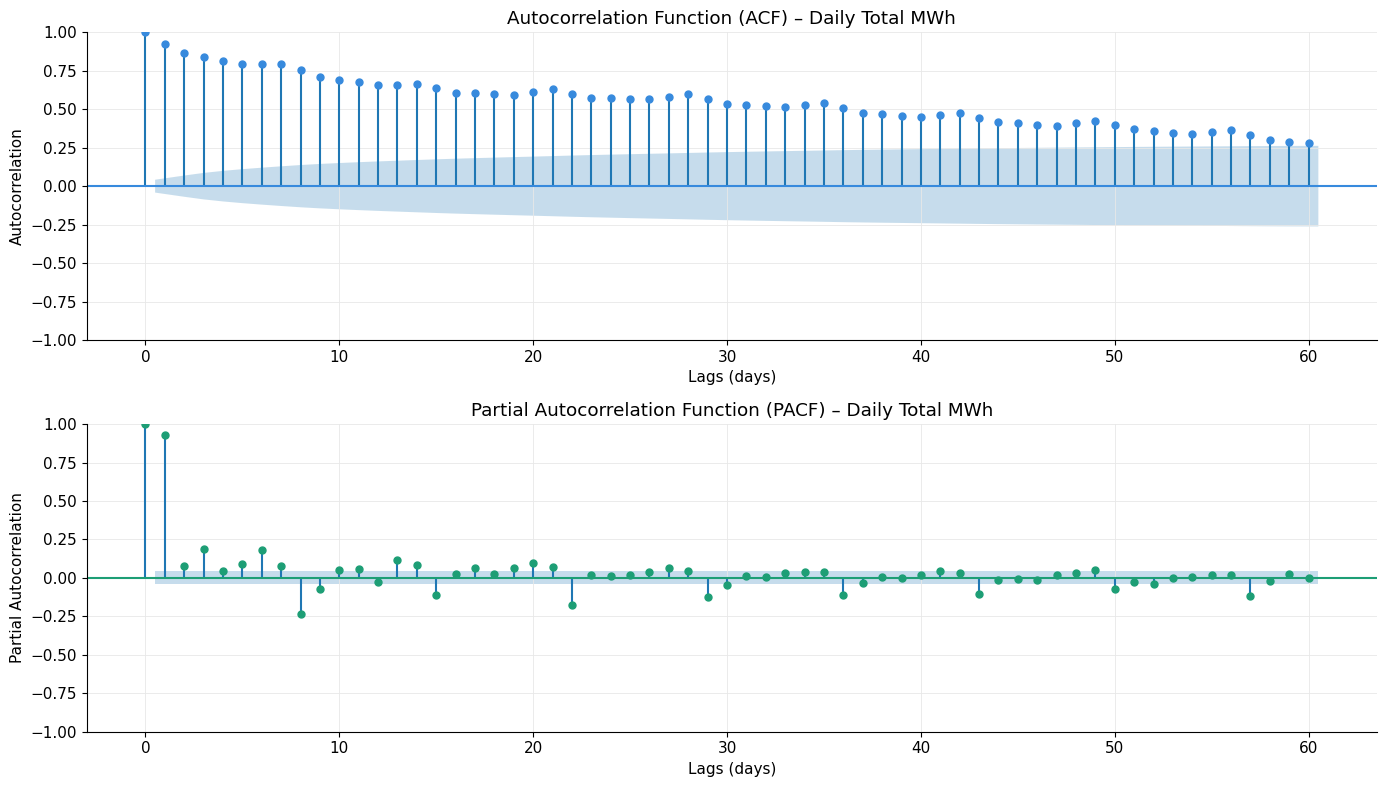

ACF shows slow decay (many significant lags) – indicates strong autocorrelation and seasonality.
PACF cuts off after lag 1 or 2 – suggests AR(1) or AR(2) component.
For daily data, significant spikes at lags 7, 14, 21,... indicate weekly seasonality.


In [32]:
# %% [markdown]
# ## 16. ACF and PACF plots

# %%
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use daily total consumption (already resampled)
daily_total = df.groupby("date")["mwh"].sum().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF
plot_acf(daily_total, ax=axes[0], lags=60, alpha=0.05, color=BLUE)
axes[0].set_title("Autocorrelation Function (ACF) – Daily Total MWh")
axes[0].set_xlabel("Lags (days)")
axes[0].set_ylabel("Autocorrelation")

# PACF
plot_pacf(daily_total, ax=axes[1], lags=60, alpha=0.05, color=GREEN, method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF) – Daily Total MWh")
axes[1].set_xlabel("Lags (days)")
axes[1].set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.savefig("13_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

# Optional: print interpretation summary
print("ACF shows slow decay (many significant lags) – indicates strong autocorrelation and seasonality.")
print("PACF cuts off after lag 1 or 2 – suggests AR(1) or AR(2) component.")
print("For daily data, significant spikes at lags 7, 14, 21,... indicate weekly seasonality.")

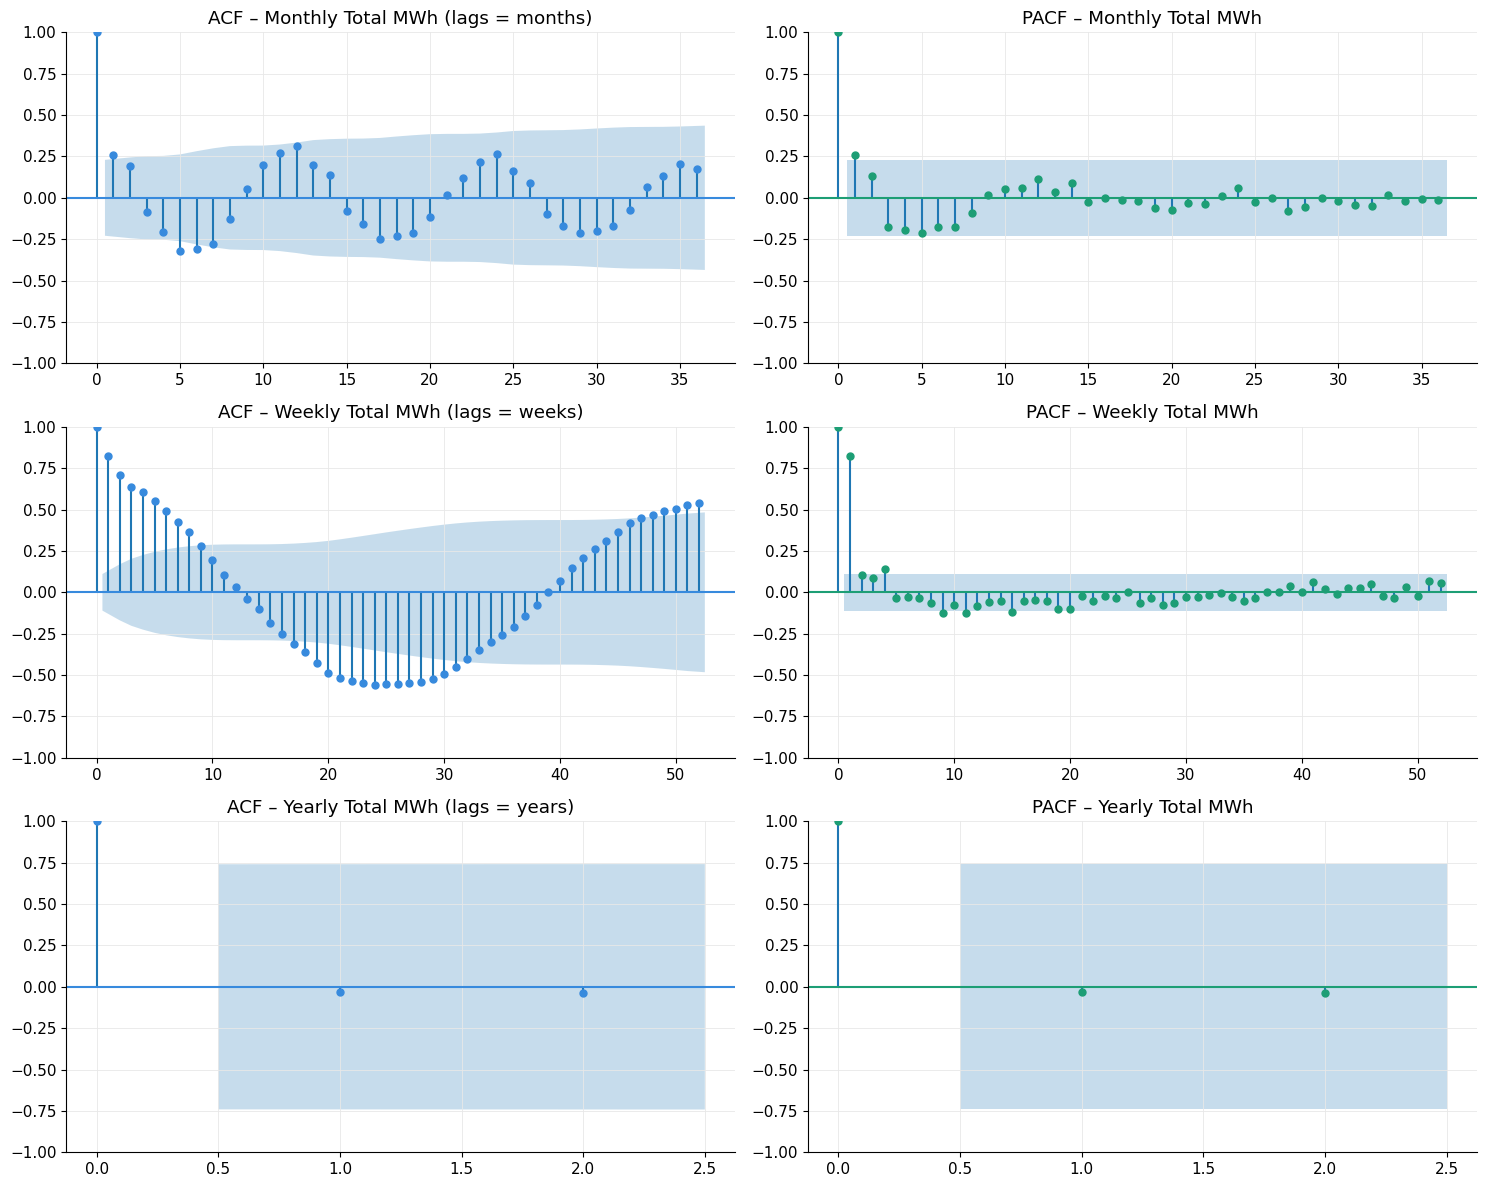


Interpretation notes:
Monthly ACF shows significant spikes at lags 12, 24,... → strong annual seasonality.
Weekly ACF shows spikes at lags 7, 14,... → weekly pattern.
Yearly series is short (≤7 points); ACF/PACF should be interpreted cautiously.


In [33]:
# %% [markdown]
# ## 17. ACF and PACF for monthly, weekly, and yearly aggregates

# %%
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Resample to different frequencies
monthly_total = df.groupby(pd.Grouper(key="start", freq="ME"))["mwh"].sum().dropna()
weekly_total = df.groupby(pd.Grouper(key="start", freq="W"))["mwh"].sum().dropna()
yearly_total = df.groupby(pd.Grouper(key="start", freq="YE"))["mwh"].sum().dropna()

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Monthly
plot_acf(monthly_total, ax=axes[0,0], lags=36, alpha=0.05, color=BLUE)
axes[0,0].set_title("ACF – Monthly Total MWh (lags = months)")
plot_pacf(monthly_total, ax=axes[0,1], lags=36, alpha=0.05, color=GREEN, method="ywm")
axes[0,1].set_title("PACF – Monthly Total MWh")

# Weekly
plot_acf(weekly_total, ax=axes[1,0], lags=52, alpha=0.05, color=BLUE)
axes[1,0].set_title("ACF – Weekly Total MWh (lags = weeks)")
plot_pacf(weekly_total, ax=axes[1,1], lags=52, alpha=0.05, color=GREEN, method="ywm")
axes[1,1].set_title("PACF – Weekly Total MWh")

# Yearly (note: short series – interpretation limited)
plot_acf(yearly_total, ax=axes[2,0], lags=min(6, len(yearly_total)//2-1), alpha=0.05, color=BLUE)
axes[2,0].set_title("ACF – Yearly Total MWh (lags = years)")
plot_pacf(yearly_total, ax=axes[2,1], lags=min(6, len(yearly_total)//2-1), alpha=0.05, color=GREEN, method="ywm")
axes[2,1].set_title("PACF – Yearly Total MWh")

plt.tight_layout()
plt.savefig("14_acf_pacf_monthly_weekly_yearly.png", dpi=150, bbox_inches="tight")
plt.show()

# Interpretation notes
print("\nInterpretation notes:")
print("Monthly ACF shows significant spikes at lags 12, 24,... → strong annual seasonality.")
print("Weekly ACF shows spikes at lags 7, 14,... → weekly pattern.")
print("Yearly series is short (≤7 points); ACF/PACF should be interpreted cautiously.")

Missing timestamps: 378


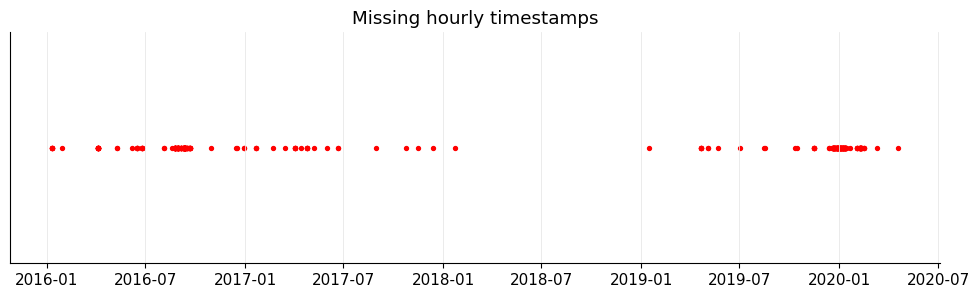

In [39]:
full_range = pd.date_range(df["start"].min(), df["start"].max(), freq="h")
missing = full_range.difference(df["start"])

print("Missing timestamps:", len(missing))

plt.figure(figsize=(12, 3))
plt.scatter(missing, [1]*len(missing), s=8, color="red")
plt.title("Missing hourly timestamps")
plt.yticks([])
plt.show()
